Min-Max Normalization

In [35]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = MinMaxScaler()

normalized_data = scaler.fit_transform(data)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=data.columns
)

print(normalized_df)

      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


Standardization (Z-Score)

In [36]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = StandardScaler()

standardized_data = scaler.fit_transform(data)

standardized_df = pd.DataFrame(
    standardized_data,
    columns=data.columns
)

print(standardized_df)

          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


Label Encoding

In [37]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

data = pd.DataFrame({
    'Branch': ['CSE', 'ECE', 'MECH', 'CSE', 'ECE']
})

encoder = LabelEncoder()

data['Encoded_Branch'] = encoder.fit_transform(
    data['Branch']
)

print(data)

  Branch  Encoded_Branch
0    CSE               0
1    ECE               1
2   MECH               2
3    CSE               0
4    ECE               1


One-Hot Encoding using Pandas

In [38]:
import pandas as pd

df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']
})

one_hot = pd.get_dummies(
    df,
    columns=['Color']
)

print(one_hot)

   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


One-Hot Encoding using Scikit-Learn

In [39]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

data = pd.DataFrame({
    'Branch': ['CSE', 'ECE', 'MECH', 'CSE', 'ECE']
})

encoder = OneHotEncoder()

result = encoder.fit_transform(
    data[['Branch']]
).toarray()

print(result)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


Normalization + Standardization + Encoding on Tips Dataset

In [40]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

tips = sns.load_dataset("tips")

numeric_cols = tips.select_dtypes(
    include=['float64', 'int64']
).columns

# Min-Max Scaling
tips_normalized = tips.copy()

scaler_minmax = MinMaxScaler()

tips_normalized[numeric_cols] = scaler_minmax.fit_transform(
    tips[numeric_cols]
)

print(tips_normalized.head())

# Standardization
tips_standardized = tips.copy()

scaler_standard = StandardScaler()

tips_standardized[numeric_cols] = scaler_standard.fit_transform(
    tips[numeric_cols]
)

print(tips_standardized.head())

# One Hot Encoding
tips_onehot = pd.get_dummies(
    tips,
    columns=['sex', 'smoker', 'day', 'time']
)

print(tips_onehot.head())

   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun  Dinner  0.453383
3    0.438315  0.225754    Male     No  Sun  Dinner -0.600193
4    0.540745  0.443020  Female     No  Sun  Dinner  1.506958
   total_bill   tip  size  sex_Male  sex_Female  smoker_Yes  smoker_No  \
0       16.99  1.01     2     False        True       False       True   
1       10.34  1.66     3      True       False       False       True   
2       21.01  3.50     3      True       False       Fals

PCA

[0.72627656 0.1730423 ]


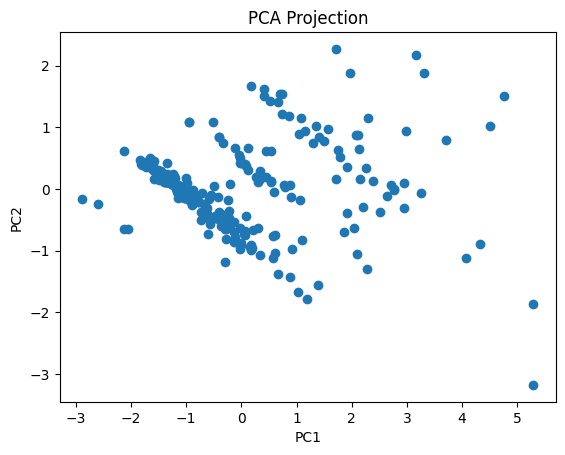

In [41]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

numeric_cols = tips.select_dtypes(
    include=['float64', 'int64']
)

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    numeric_cols
)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print(pca.explained_variance_ratio_)

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

LDA

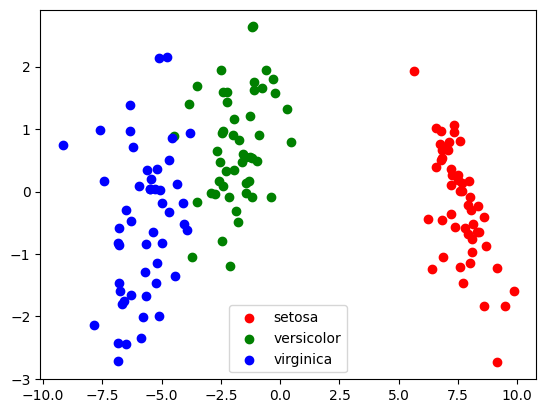

In [42]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2']
)

lda_df['target'] = y

for label, color in zip(
    [0, 1, 2],
    ['red', 'green', 'blue']
):
    plt.scatter(
        lda_df[lda_df['target'] == label]['LD1'],
        lda_df[lda_df['target'] == label]['LD2'],
        color=color,
        label=iris.target_names[label]
    )

plt.legend()
plt.show()